# Null split sulla root: River vs CapyMOA

Questo notebook verifica il caso limite in cui la root leaf non crea alcun attribute observer perché l'unica feature è sempre missing. Al primo tentativo di split:

- con `merit_preprune=True`, l'unico candidato è il null split con merit `-inf`: la root viene disattivata;
- con `merit_preprune=False`, la lista dei candidati è vuota: la root rimane attiva.

Lo stesso esperimento viene eseguito in River e nel port HATR usato tramite CapyMOA. Usiamo `stop_mem_management=True`: in River, dopo il pre-pruning, il memory manager condiviso può altrimenti riattivare immediatamente l'unica foglia e nascondere la transizione nei contatori.

## Setup

Il JAR HATR deve essere compilato prima di avviare il kernel:

```bash
cd ../implementation/hatr-moa
mvn package -DskipTests
```

In [1]:
import os
import sys
from pathlib import Path

import jpype
import jpype.config

jpype.config.destroy_jvm = False

# Funziona sia avviando Jupyter da experiments/ sia dalla directory andrea_zhang/.
cwd = Path.cwd().resolve()
PROJECT_DIR = cwd.parent if cwd.name == 'experiments' else cwd
IMPLEMENTATION_DIR = PROJECT_DIR / 'implementation'
HATR_JAR = (IMPLEMENTATION_DIR / 'hatr-moa' / 'target' /
            'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar')

assert HATR_JAR.exists(), (
    f'JAR non trovato: {HATR_JAR}\n'
    'Compilare con: cd ../implementation/hatr-moa && mvn package -DskipTests'
)

if jpype.isJVMStarted():
    print('JVM già avviata: se la classe HATR non è disponibile, riavviare il kernel.')
else:
    jpype.addClassPath(str(HATR_JAR))

sys.path.insert(0, str(IMPLEMENTATION_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from capymoa.instance import RegressionInstance
from capymoa.stream import Schema
from river import tree as river_tree
from hatr_capymoa import HoeffdingAdaptiveTreeRegressor as CapyHATR

print('Setup OK')

Setup OK


## Stream senza feature osservabili

Per River una feature mancante può essere omessa dal dizionario, quindi ogni `x` è `{}`. CapyMOA richiede invece un vettore coerente con lo schema: la stessa informazione mancante è rappresentata con `NaN`. Il target varia, ma non influenza la creazione degli attribute observer.

Il bootstrap è disattivato per far coincidere esattamente il peso osservato con il numero di campioni. Con `grace_period=20`, il primo tentativo avviene al campione 20.

In [2]:
N_SAMPLES = 60
GRACE_PERIOD = 20

targets = np.sin(np.arange(N_SAMPLES) / 5.0)
river_features = [{} for _ in range(N_SAMPLES)]
capymoa_features = np.full((N_SAMPLES, 1), np.nan)

schema = Schema.from_custom(
    features=['x', 'target'],
    target='target',
    name='all_missing_feature',
)

pd.DataFrame({'x': capymoa_features[:, 0], 'target': targets}).head(8)

,x,target
0,NaN,0.000000
1,NaN,0.198669
2,NaN,0.389418
3,NaN,0.564642
4,NaN,0.717356
5,NaN,0.841471
6,NaN,0.932039
7,NaN,0.985450


## Esperimento

Dopo ogni aggiornamento registriamo nodi, foglie attive e foglie inattive. `memory_estimate_period` è impostato oltre la lunghezza dello stream e `stop_mem_management=True` impedisce al tracker di River di riattivare immediatamente la root appena disattivata. In questo modo il contatore rende visibile l'esito del null split.

In [3]:
def river_structure(model):
    summary = model.summary
    return {
        'nodes': int(summary.get('n_nodes', 0)),
        'leaves': int(summary.get('n_leaves', 0)),
        'active': int(summary.get('n_active_leaves', 0)),
        'inactive': int(summary.get('n_inactive_leaves', 0)),
    }


def capymoa_structure(model):
    measurements = {
        item.getName(): item.getValue()
        for item in model.moa_learner.getModelMeasurements()
    }
    return {
        'nodes': int(measurements.get('tree nodes', 0)),
        'leaves': int(measurements.get('tree leaves', 0)),
        'active': int(measurements.get('active leaves', 0)),
        'inactive': int(measurements.get('inactive leaves', 0)),
    }


def run_experiment(merit_preprune):
    river_model = river_tree.HoeffdingAdaptiveTreeRegressor(
        grace_period=GRACE_PERIOD,
        leaf_prediction='mean',
        bootstrap_sampling=False,
        merit_preprune=merit_preprune,
        stop_mem_management=True,
        seed=0,
    )
    capymoa_model = CapyHATR(
        schema=schema,
        grace_period=GRACE_PERIOD,
        leaf_prediction='mean',
        bootstrap_sampling=False,
        merit_preprune=merit_preprune,
        memory_estimate_period=N_SAMPLES + 1,
        stop_mem_management=True,
        random_seed=0,
    )

    rows = []
    for i, y in enumerate(targets, start=1):
        river_model.learn_one(river_features[i - 1], float(y))
        capymoa_instance = RegressionInstance(
            schema, (capymoa_features[i - 1], float(y))
        )
        capymoa_model.train(capymoa_instance)

        for framework, structure in (
            ('River', river_structure(river_model)),
            ('CapyMOA', capymoa_structure(capymoa_model)),
        ):
            rows.append({
                'sample': i,
                'merit_preprune': merit_preprune,
                'framework': framework,
                **structure,
            })

    return rows


history = pd.DataFrame(
    run_experiment(True) + run_experiment(False)
)
history.head()

Can not access instrumentation environment.
Please check if jar file containing SizeOfAgent class is 
specified in the java's "-javaagent" command line argument.


,sample,merit_preprune,framework,nodes,leaves,active,inactive
0,1,True,River,1,1,1,0
1,1,True,CapyMOA,1,1,1,0
2,2,True,River,1,1,1,0
3,2,True,CapyMOA,1,1,1,0
4,3,True,River,1,1,1,0


## Risultati ed equivalenza

Mostriamo i campioni immediatamente prima e dopo il primo tentativo di split.

In [4]:
checkpoints = [1, GRACE_PERIOD - 1, GRACE_PERIOD, GRACE_PERIOD + 1, N_SAMPLES]
snapshot = history.loc[
    history['sample'].isin(checkpoints),
    ['sample', 'merit_preprune', 'framework', 'nodes', 'leaves', 'active', 'inactive'],
].sort_values(['merit_preprune', 'sample', 'framework'], ascending=[False, True, True])
snapshot

,sample,merit_preprune,framework,nodes,leaves,active,inactive
1,1,True,CapyMOA,1,1,1,0
0,1,True,River,1,1,1,0
37,19,True,CapyMOA,1,1,1,0
36,19,True,River,1,1,1,0
39,20,True,CapyMOA,1,1,0,1
38,20,True,River,1,1,0,1
41,21,True,CapyMOA,1,1,0,1
40,21,True,River,1,1,0,1
119,60,True,CapyMOA,1,1,0,1
118,60,True,River,1,1,0,1


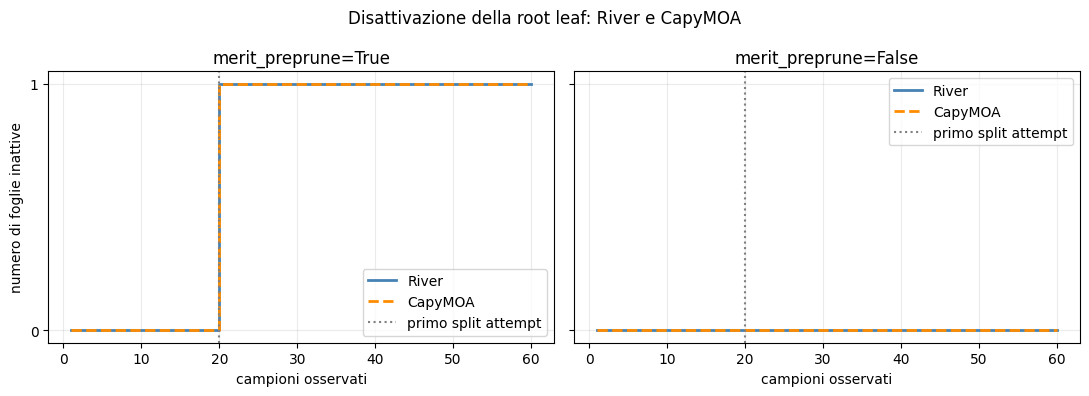

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
colors = {'River': 'steelblue', 'CapyMOA': 'darkorange'}
styles = {'River': '-', 'CapyMOA': '--'}

for ax, merit_preprune in zip(axes, [True, False]):
    subset = history[history['merit_preprune'] == merit_preprune]
    for framework in ['River', 'CapyMOA']:
        data = subset[subset['framework'] == framework]
        ax.step(
            data['sample'], data['inactive'], where='post',
            label=framework, color=colors[framework],
            linestyle=styles[framework], linewidth=2,
        )
    ax.axvline(GRACE_PERIOD, color='grey', linestyle=':',
               label='primo split attempt')
    ax.set_title(f'merit_preprune={merit_preprune}')
    ax.set_xlabel('campioni osservati')
    ax.set_yticks([0, 1])
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel('numero di foglie inattive')
fig.suptitle('Disattivazione della root leaf: River e CapyMOA')
fig.tight_layout()
plt.show()

In [6]:
# Le due implementazioni devono coincidere a ogni campione.
wide = history.pivot(
    index=['sample', 'merit_preprune'],
    columns='framework',
    values=['nodes', 'leaves', 'active', 'inactive'],
)
for metric in ['nodes', 'leaves', 'active', 'inactive']:
    assert (wide[(metric, 'River')] == wide[(metric, 'CapyMOA')]).all(), metric

final = history[history['sample'] == N_SAMPLES]
with_preprune = final[final['merit_preprune']]
without_preprune = final[~final['merit_preprune']]

assert (with_preprune['inactive'] == 1).all()
assert (with_preprune['active'] == 0).all()
assert (without_preprune['inactive'] == 0).all()
assert (without_preprune['active'] == 1).all()

print('OK: River e CapyMOA coincidono a ogni campione.')
print('OK: merit_preprune=True  -> inactive leaves: 0 -> 1')
print('OK: merit_preprune=False -> inactive leaves: resta 0')

OK: River e CapyMOA coincidono a ogni campione.
OK: merit_preprune=True  -> inactive leaves: 0 -> 1
OK: merit_preprune=False -> inactive leaves: resta 0


## Conclusione

Con `merit_preprune=True`, al campione `grace_period` la lista contiene soltanto il null split: la root rimane l'unico nodo, ma passa da foglia attiva a foglia inattiva. Con `merit_preprune=False`, la lista è vuota e non avviene alcuna disattivazione. River e CapyMOA producono la stessa traiettoria strutturale per entrambe le configurazioni.